<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/06_1_data_augmentation_for_text_using_smote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation for Text using SMOTE

We will explore the use of SMOTE (Synthetic Minority Over-sampling Technique) for handling imbalanced datasets, particularly in text classification tasks. While SMOTE is commonly applied to numerical data, we will examine its applicability and limitations in natural language processing (NLP), including methods to adapt it to text data.

In [56]:
import nltk
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from nltk.corpus import movie_reviews
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

In [57]:
# Download the dataset if not already present
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [58]:
# Load movie reviews (1000 pos / 1000 neg)
documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Shuffling ensures random distribution of positive and negative samples
random.shuffle(documents)

In [59]:
# Extract texts and labels
texts = [text for text, label in documents]
labels = [1 if label == 'pos' else 0 for text, label in documents]  # pos=1, neg=0

In [60]:
# Simulate imbalance: keep all positives, downsample negatives
positive_texts = [t for t, l in zip(texts, labels) if l == 1]
negative_texts = [t for t, l in zip(texts, labels) if l == 0][:200]  # imbalance

texts_imbalanced = positive_texts + negative_texts
labels_imbalanced = [1] * len(positive_texts) + [0] * len(negative_texts)

In [61]:
# Example Positive Review
print(labels[0])
print(positive_texts[0])

1
no , it is not a bad film , in fact it is so good in achieving its = purpose , i actually wished for the film to end itself quickly . 
event = horizon is not your run-of-the-mill sci-fi film , i'm sure many who have = watched this will agree with me . 
it is not even original in that sense , = and it does borrow heavily from films like alien , hellraiser and even = blade runner . 
the magic of this film lies in its unorthodox setting and = methodical build-up that makes it wonderfully horrifying . 
the story brings us to the year 2050 , where space travel have since = enormously progressed . 
the event horizon is actually a ship built for a = secret experimental purpose ; it has the ability to fold time and space = thus making it possible for travelling distances not reachable in a = man's lifetime . 
the ship disappeared as soon as it went into operation = but after 7 years , it reappeared again within the orbit of neptune . 
a = search and rescue team led by miller ( fishburne ) is

In [62]:
# Vectorize
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts_imbalanced).toarray()
y = np.array(labels_imbalanced)

In [63]:
# PCA before SMOTE
pca = PCA(n_components=2)
X_pca_before = pca.fit_transform(X)

# SMOTE
smote = SMOTE(k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X, y)

# PCA after SMOTE
X_pca_after = pca.fit_transform(X_resampled)

## Visualization Explanation
- Left chart: Skewed distribution (e.g., many blue = positive, few red = negative).
- Right chart: Balanced classes after SMOTE (equal representation in PCA space).

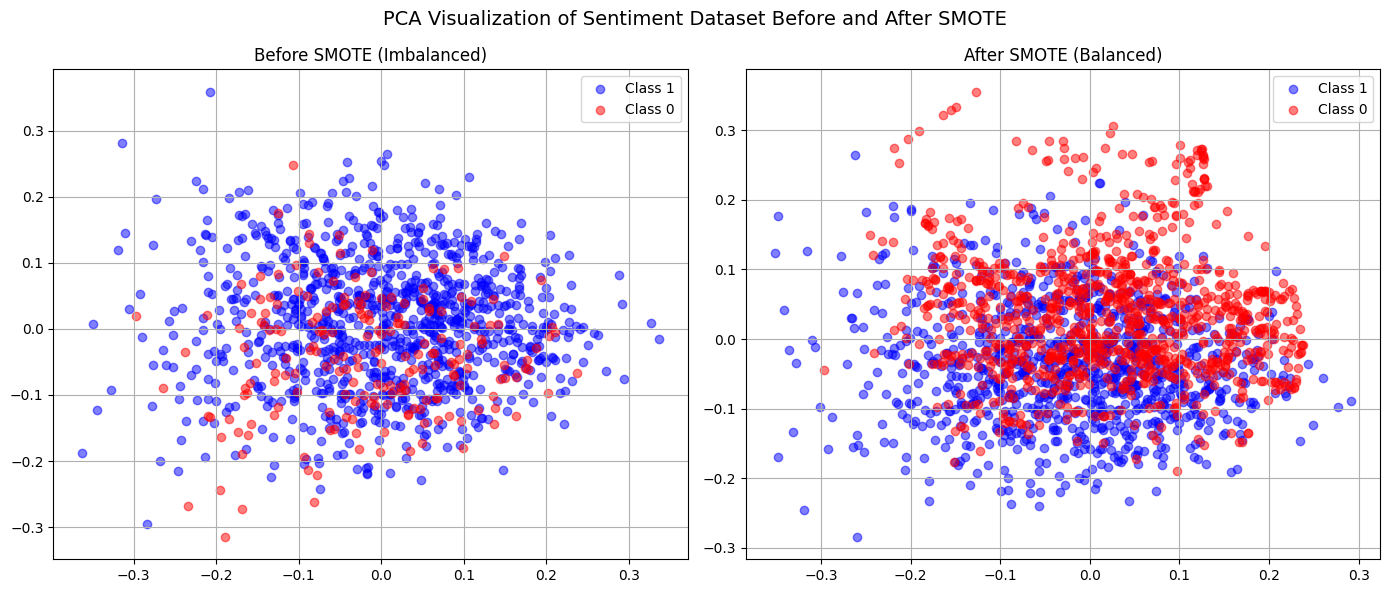

In [64]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Before SMOTE
df_before = pd.DataFrame(X_pca_before, columns=["PC1", "PC2"])
df_before["Label"] = y
colors = {0: "red", 1: "blue"}
for label in df_before["Label"].unique():
    subset = df_before[df_before["Label"] == label]
    axs[0].scatter(subset["PC1"], subset["PC2"], c=colors[label], label=f"Class {label}", alpha=0.5)
axs[0].set_title("Before SMOTE (Imbalanced)")
axs[0].legend()
axs[0].grid(True)

# After SMOTE
df_after = pd.DataFrame(X_pca_after, columns=["PC1", "PC2"])
df_after["Label"] = y_resampled
for label in df_after["Label"].unique():
    subset = df_after[df_after["Label"] == label]
    axs[1].scatter(subset["PC1"], subset["PC2"], c=colors[label], label=f"Class {label}", alpha=0.5)
axs[1].set_title("After SMOTE (Balanced)")
axs[1].legend()
axs[1].grid(True)

plt.suptitle("PCA Visualization of Sentiment Dataset Before and After SMOTE", fontsize=14)
plt.tight_layout()
plt.show()